In [74]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt


In [75]:
pasta = "Dados"

resultados = []

for arquivo in os.listdir(pasta):

    match = re.search(r'(\d+)_ul', arquivo)

    if match:
        ml = int(match.group(1))

        caminho = os.path.join(pasta, arquivo)

        df = pd.read_csv(caminho)

        red_mean = df["red"].mean()
        green_mean = df["green"].mean()
        blue_mean = df["blue"].mean()

        red_std = df["red"].std()
        green_std = df["green"].std()
        blue_std = df["blue"].std()

        resultados.append({
            "ul": ml,

            "red_mean": red_mean,
            "green_mean": green_mean,
            "blue_mean": blue_mean,

            "red_std": red_std,
            "green_std": green_std,
            "blue_std": blue_std
        })

# Cria DataFrame final
dados = pd.DataFrame(resultados)

# Ordena por volume
dados = dados.sort_values("ul")



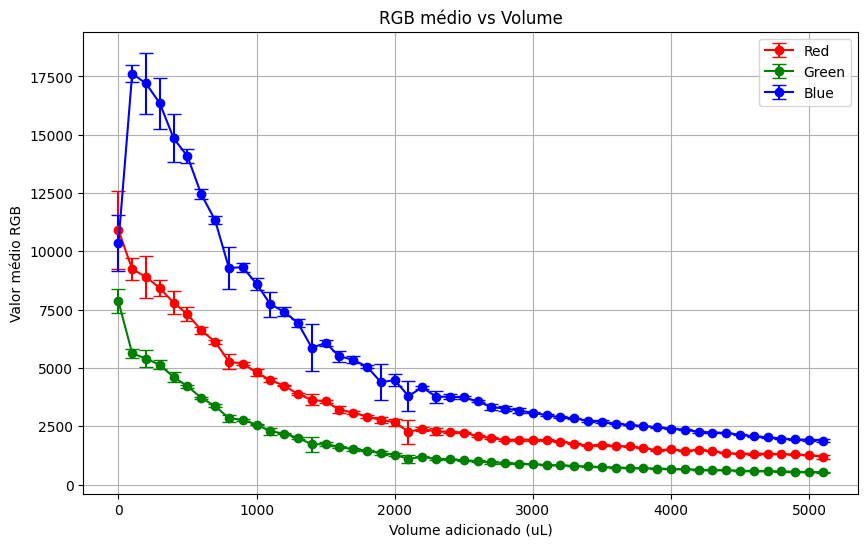

In [76]:
# =========================
# PLOT
# =========================

plt.figure(figsize=(10,6))

# Red
plt.errorbar(
    dados["ul"],
    dados["red_mean"],
    yerr=dados["red_std"],
    fmt='-o',
    capsize=5,
    label='Red',
    color= 'red'
)

# Green
plt.errorbar(
    dados["ul"],
    dados["green_mean"],
    yerr=dados["green_std"],
    fmt='-o',
    capsize=5,
    label='Green',
    color='green'
)

# Blue
plt.errorbar(
    dados["ul"],
    dados["blue_mean"],
    yerr=dados["blue_std"],
    fmt='-o',
    capsize=5,
    label='Blue',
    color='blue'
)

plt.xlabel("Volume adicionado (uL)")
plt.ylabel("Valor médio RGB")
plt.title("RGB médio vs Volume")
plt.legend()

plt.grid(True)

plt.show()